In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime as dt
df_org_PQ = pd.read_csv("shipments.csv")

pd.set_option('display.max_columns', None)

head = df_org_PQ.head(20)
samples = df_org_PQ.sample(10)
describe_all = df_org_PQ.describe(include='all').round(2)
describe_figures = df_org_PQ.describe()

print("\n>>> HEAD: ")
display(head)
print("\n\n>>> DF INFO: ")
df_org_PQ.info()



>>> HEAD: 


,shipment_id,timestamp,severity,thread,source,event,station,box_barcode,articles,exp_weight_kg,act_weight_kg,tare_weight_kg,product_weight_kg,abs_weight_diff,print_quality_pct,line_speed_mps,slam,iso_grade,pckg_problem_found,weight_diff,weight_diff_ratio,distance_to_threshold,is_kot
0,Sp260320125716,2026-01-12 00:02:12.737,INFO,LabelThread-4,com.logistic.labelmachine.SystemManager,Label printed,Station-06,BC_LARGE400,2.0,4.370,4.48296,0.13,4.35296,0.01704,100.00000,1.40,SLAM5_LP1,A,NaN,0.01704,0.004,-0.035400,0
1,Sp260320125717,2026-01-12 00:02:26.481,INFO,LabelThread-2,com.logistic.labelmachine.SystemManager,Label printed,Station-07,RK_SMALL90,18.0,2.507,2.60143,0.12,2.48143,0.02557,99.96875,1.39,SLAM5_LP2,A,NaN,0.02557,0.010,-0.004514,0
2,Sp260320125718,2026-01-12 00:02:39.520,INFO,LabelThread-1,com.logistic.labelmachine.SystemManager,Label printed,Station-03,RK_SMALL90,9.0,1.770,1.88150,0.12,1.76150,0.00850,99.91250,1.67,SLAM5_LP1,A,NaN,0.00850,0.005,-0.012740,0
3,Sp260320125719,2026-01-12 00:02:51.721,INFO,LabelThread-3,com.logistic.labelmachine.SystemManager,Label printed,Station-03,BC_SMALL100,12.0,2.382,2.48724,0.09,2.39724,0.01524,99.88125,2.07,SLAM5_LP2,A,NaN,-0.01524,0.006,-0.013344,0
4,Sp260320125720,2026-01-12 00:03:05.377,INFO,main,com.logistic.labelmachine.SystemManager,Package processed successfully,Station-04,BC_SMALL100,16.0,5.291,5.31857,0.09,5.22857,0.06243,99.82500,1.96,SLAM5_LP1,A,NaN,0.06243,0.012,-0.001062,0
5,Sp260320125721,2026-01-12 00:03:19.709,WARN,KickoutThread-1,com.logistic.conveyer.ScaleHandlerSys,Overweight detected,Station-12,RK_SMALL70,17.0,3.286,3.26066,0.09,3.17066,0.11534,NaN,NaN,NaN,NaN,N,0.11534,0.035,0.075908,1
6,Sp260320125722,2026-01-12 00:03:32.108,INFO,LabelThread-2,com.logistic.labelmachine.SystemManager,Label printed,Station-03,XX_LARGE60,5.0,1.987,2.23515,0.24,1.99515,0.00815,99.79375,0.90,SLAM5_LP2,A,NaN,-0.00815,0.004,-0.015694,0
7,Sp260320125723,2026-01-12 00:03:45.079,INFO,LabelThread-4,com.logistic.labelmachine.SystemManager,Label printed,Station-02,XX_LARGE60,4.0,3.151,3.37777,0.24,3.13777,0.01323,99.73750,0.89,SLAM5_LP1,A,NaN,0.01323,0.004,-0.024582,0
8,Sp260320125724,2026-01-12 00:03:58.508,WARN,KickoutThread-1,com.logistic.conveyer.ScaleHandlerSys,Overweight detected,Station-03,RK_SMALL90,10.0,1.249,1.32266,0.12,1.20266,0.04634,NaN,NaN,NaN,NaN,N,0.04634,0.037,0.031352,1
9,Sp260320125725,2026-01-12 00:04:13.423,INFO,main,com.logistic.labelmachine.SystemManager,Package processed successfully,Station-04,RK_SMALL70,8.0,0.383,0.47587,0.09,0.38587,0.00287,99.70625,2.36,SLAM5_LP2,A,NaN,-0.00287,0.007,-0.001726,0




>>> DF INFO: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5893 entries, 0 to 5892
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   shipment_id            5893 non-null   object 
 1   timestamp              5893 non-null   object 
 2   severity               5893 non-null   object 
 3   thread                 5893 non-null   object 
 4   source                 5893 non-null   object 
 5   event                  5893 non-null   object 
 6   station                5750 non-null   object 
 7   box_barcode            5893 non-null   object 
 8   articles               5750 non-null   float64
 9   exp_weight_kg          5750 non-null   float64
 10  act_weight_kg          5750 non-null   float64
 11  tare_weight_kg         5750 non-null   float64
 12  product_weight_kg      5750 non-null   float64
 13  abs_weight_diff        5750 non-null   float64
 14  print_quality_pct      4425 non-null   f

In [6]:
# 1) umwandeln in Pandas-Zeitwert von Format 'O' in <M8[ms]
df_org_PQ['timestamp'] = pd.to_datetime(df_org_PQ['timestamp'])

# 2) Milliselunden entfernen. Format von: <M8[ms] auf: <M8[s]
df_org_PQ['timestamp'] = df_org_PQ['timestamp'].astype('datetime64[s]')

df_org_PQ['timestamp'].dtype


dtype('<M8[s]')

In [8]:
# prüfen, ob in Spalte 'SlamPrinter' die beiden Drucker auch wirklich immer zeilenweise abwechselnd vorkommen
is_alternating = (df_org_PQ['slam'] != df_org_PQ['slam'].shift()).all()
is_alternating


np.False_

In [9]:
# Spalte Shipments entfernen, wird nicht mehr gebraucht
df_org_PQ = df_org_PQ.drop(columns=["shipment_id"])

# Spalte PrintQuality umbennenn in verständlicher Prozessbeschreibung
df_org_PQ.rename(columns={'print_quality_pct': 'Tonerstatus_beforePrint'}, inplace=True)

# Tonerstatus nach Druckvorgang in gleiche Zeile übernehmen, sowie Umbennennung für Prozessbschreibung
df_org_PQ['Tonerstatus_afterPrint'] = df_org_PQ['Tonerstatus_beforePrint'].shift(-1)

# Tonerverbrauch anzeigen
df_org_PQ['ink_usage'] = df_org_PQ['Tonerstatus_beforePrint'] - df_org_PQ['Tonerstatus_afterPrint']

df_org_PQ.head(20)


,timestamp,severity,thread,source,event,station,box_barcode,articles,exp_weight_kg,act_weight_kg,tare_weight_kg,product_weight_kg,abs_weight_diff,Tonerstatus_beforePrint,line_speed_mps,slam,iso_grade,pckg_problem_found,weight_diff,weight_diff_ratio,distance_to_threshold,is_kot,Tonerstatus_afterPrint,ink_usage
0,2026-01-12 00:02:12,INFO,LabelThread-4,com.logistic.labelmachine.SystemManager,Label printed,Station-06,BC_LARGE400,2.0,4.370,4.48296,0.13,4.35296,0.01704,100.00000,1.40,SLAM5_LP1,A,NaN,0.01704,0.004,-0.035400,0,99.96875,0.03125
1,2026-01-12 00:02:26,INFO,LabelThread-2,com.logistic.labelmachine.SystemManager,Label printed,Station-07,RK_SMALL90,18.0,2.507,2.60143,0.12,2.48143,0.02557,99.96875,1.39,SLAM5_LP2,A,NaN,0.02557,0.010,-0.004514,0,99.91250,0.05625
2,2026-01-12 00:02:39,INFO,LabelThread-1,com.logistic.labelmachine.SystemManager,Label printed,Station-03,RK_SMALL90,9.0,1.770,1.88150,0.12,1.76150,0.00850,99.91250,1.67,SLAM5_LP1,A,NaN,0.00850,0.005,-0.012740,0,99.88125,0.03125
3,2026-01-12 00:02:51,INFO,LabelThread-3,com.logistic.labelmachine.SystemManager,Label printed,Station-03,BC_SMALL100,12.0,2.382,2.48724,0.09,2.39724,0.01524,99.88125,2.07,SLAM5_LP2,A,NaN,-0.01524,0.006,-0.013344,0,99.82500,0.05625
4,2026-01-12 00:03:05,INFO,main,com.logistic.labelmachine.SystemManager,Package processed successfully,Station-04,BC_SMALL100,16.0,5.291,5.31857,0.09,5.22857,0.06243,99.82500,1.96,SLAM5_LP1,A,NaN,0.06243,0.012,-0.001062,0,NaN,NaN
5,2026-01-12 00:03:19,WARN,KickoutThread-1,com.logistic.conveyer.ScaleHandlerSys,Overweight detected,Station-12,RK_SMALL70,17.0,3.286,3.26066,0.09,3.17066,0.11534,NaN,NaN,NaN,NaN,N,0.11534,0.035,0.075908,1,99.79375,NaN
6,2026-01-12 00:03:32,INFO,LabelThread-2,com.logistic.labelmachine.SystemManager,Label printed,Station-03,XX_LARGE60,5.0,1.987,2.23515,0.24,1.99515,0.00815,99.79375,0.90,SLAM5_LP2,A,NaN,-0.00815,0.004,-0.015694,0,99.73750,0.05625
7,2026-01-12 00:03:45,INFO,LabelThread-4,com.logistic.labelmachine.SystemManager,Label printed,Station-02,XX_LARGE60,4.0,3.151,3.37777,0.24,3.13777,0.01323,99.73750,0.89,SLAM5_LP1,A,NaN,0.01323,0.004,-0.024582,0,NaN,NaN
8,2026-01-12 00:03:58,WARN,KickoutThread-1,com.logistic.conveyer.ScaleHandlerSys,Overweight detected,Station-03,RK_SMALL90,10.0,1.249,1.32266,0.12,1.20266,0.04634,NaN,NaN,NaN,NaN,N,0.04634,0.037,0.031352,1,99.70625,NaN
9,2026-01-12 00:04:13,INFO,main,com.logistic.labelmachine.SystemManager,Package processed successfully,Station-04,RK_SMALL70,8.0,0.383,0.47587,0.09,0.38587,0.00287,99.70625,2.36,SLAM5_LP2,A,NaN,-0.00287,0.007,-0.001726,0,99.65000,0.05625


In [10]:
# Datensatz anschauen, Verhalten in Spalte ink-usage verstehen
df_org_PQ.describe()


,timestamp,articles,exp_weight_kg,act_weight_kg,tare_weight_kg,product_weight_kg,abs_weight_diff,Tonerstatus_beforePrint,line_speed_mps,weight_diff,weight_diff_ratio,distance_to_threshold,is_kot,Tonerstatus_afterPrint,ink_usage
count,5893,5750.000000,5750.000000,5750.000000,5750.000000,5750.000000,5750.000000,4425.000000,4425.000000,5750.000000,5750.000000,5750.000000,5893.000000,4424.000000,3330.000000
mean,2026-01-12 11:27:27,10.686435,3.164804,3.311188,0.144376,3.166812,0.045860,94.037181,1.604050,-0.002008,0.014462,0.007882,0.224843,94.035833,-0.006999
min,2026-01-12 00:02:12,1.000000,0.380000,0.453980,0.070000,0.376880,0.001260,88.012500,0.800000,-0.375580,0.003000,-0.053336,0.000000,88.012500,-11.987500
25%,2026-01-12 05:34:05,6.000000,1.752250,1.885728,0.090000,1.755143,0.014105,91.018750,1.220000,-0.027487,0.006000,-0.017837,0.000000,91.018750,0.031250
50%,2026-01-12 11:11:04,11.000000,3.152000,3.290175,0.120000,3.155590,0.026035,94.050000,1.600000,-0.002940,0.009000,-0.006982,0.000000,94.050000,0.031250
75%,2026-01-12 17:01:33,16.000000,4.556750,4.692723,0.240000,4.560837,0.047685,97.056250,2.000000,0.024990,0.012000,-0.000487,0.000000,97.056250,0.056250
max,2026-01-12 23:59:11,20.000000,6.000000,6.518040,0.290000,6.327000,0.375580,100.000000,2.400000,0.370550,0.065000,0.306028,1.000000,100.000000,0.087500
std,NaN,5.759179,1.619009,1.626837,0.074294,1.622971,0.058032,3.487986,0.457555,0.073940,0.014837,0.053153,0.417514,3.487227,0.778682


In [11]:
# Werte in Spalte 'ink_usage' runden und visuell prüfen was es in der Spalte an Werten gibt
df_org_PQ["ink_usage"] = round(df_org_PQ["ink_usage"],3)
df_org_PQ['ink_usage'].value_counts()


ink_usage
 0.031     1661
 0.056     1646
-11.988      14
-0.088        3
 0.088        3
-0.031        2
 0.087        1
Name: count, dtype: int64

In [12]:
# Alle Werte -11.99 anzeigen, um diese Ausreißer einzusehen und für Angeichung an die anderen Werte vorzubereiten
df_org_PQ_check = df_org_PQ[df_org_PQ["ink_usage"] <= -11.98]
df_org_PQ_check


,timestamp,severity,thread,source,event,station,box_barcode,articles,exp_weight_kg,act_weight_kg,tare_weight_kg,product_weight_kg,abs_weight_diff,Tonerstatus_beforePrint,line_speed_mps,slam,iso_grade,pckg_problem_found,weight_diff,weight_diff_ratio,distance_to_threshold,is_kot,Tonerstatus_afterPrint,ink_usage
370,2026-01-12 01:25:47,INFO,MaintenanceThread-1,com.logistic.labelmachine.PrintManager,"Resolved, print quality to normal (100.0%). Re...",Station-01,XX_LARGE80,14.0,4.498,4.81769,0.29,4.52769,0.02969,88.0125,0.98,SLAM5_LP1,A,NaN,-0.02969,0.007,-0.024286,0,100.0,-11.988
1457,2026-01-12 05:30:27,INFO,LabelThread-4,com.logistic.labelmachine.SystemManager,Label printed,Station-12,RK_SMALL70,20.0,2.708,2.81289,0.09,2.72289,0.01489,88.0125,1.14,SLAM5_LP2,A,NaN,-0.01489,0.005,-0.017606,0,100.0,-11.988
1867,2026-01-12 07:07:58,INFO,LabelThread-2,com.logistic.labelmachine.SystemManager,Label printed,Station-11,XX_LARGE60,6.0,2.034,2.28234,0.24,2.04234,0.00834,88.0125,2.23,SLAM5_LP1,A,NaN,-0.00834,0.004,-0.016068,0,100.0,-11.988
2240,2026-01-12 08:32:06,INFO,LabelThread-2,com.logistic.labelmachine.SystemManager,Label printed,Station-08,BC_SMALL100,5.0,3.501,3.57349,0.09,3.48349,0.01751,88.0125,0.96,SLAM5_LP2,A,NaN,0.01751,0.005,-0.024502,0,100.0,-11.988
2603,2026-01-12 09:53:27,INFO,main,com.logistic.labelmachine.SystemManager,Package processed successfully,Station-03,RK_SMALL70,9.0,1.493,1.57255,0.09,1.48255,0.01045,88.0125,2.36,SLAM5_LP1,A,NaN,0.01045,0.007,-0.007466,0,100.0,-11.988
2945,2026-01-12 11:10:50,INFO,VerifyThread-1,com.logistic.labelmachine.SystemManager,Verification successful,Station-08,XX_LARGE60,11.0,2.111,2.34087,0.24,2.10087,0.01013,88.0125,0.81,SLAM5_LP2,A,NaN,0.01013,0.005,-0.015202,0,100.0,-11.988
3318,2026-01-12 12:34:47,INFO,main,com.logistic.labelmachine.SystemManager,Package processed successfully,Station-06,RK_SMALL90,2.0,2.406,2.54838,0.12,2.42838,0.02238,88.0125,1.64,SLAM5_LP1,A,NaN,-0.02238,0.009,-0.006492,0,100.0,-11.988
3675,2026-01-12 13:54:46,INFO,LabelThread-4,com.logistic.labelmachine.SystemManager,Label printed,Station-05,XX_LARGE60,3.0,5.222,5.41605,0.24,5.17605,0.04595,88.0125,1.20,SLAM5_LP2,A,NaN,0.04595,0.009,-0.016714,0,100.0,-11.988
4015,2026-01-12 15:16:45,INFO,MaintenanceThread-1,com.logistic.labelmachine.PrintManager,"Resolved, print quality to normal (100.0%). Re...",Station-07,RK_SMALL60,19.0,0.739,0.80649,0.07,0.73649,0.00251,88.0125,2.36,SLAM5_LP1,A,NaN,0.00251,0.003,-0.006358,0,100.0,-11.988
4374,2026-01-12 16:48:43,INFO,LabelThread-4,com.logistic.labelmachine.SystemManager,Label printed,Station-01,BC_SMALL100,4.0,2.594,2.71227,0.09,2.62227,0.02827,88.0125,0.86,SLAM5_LP2,A,NaN,-0.02827,0.011,-0.002858,0,100.0,-11.988


In [14]:
# alle Ausreißer mit -11.9 jetzt als Mittelwerte der jeweiligen SlamPrinter festlegen
means = df_org_PQ[df_org_PQ['ink_usage'] > -11.98].groupby('slam')['ink_usage'].mean()
df_org_PQ['ink_usage'] = df_org_PQ.apply(
    lambda row: means[row['slam']] if row['ink_usage'] <= -11.98 else row['ink_usage'],
    axis=1
)
print(df_org_PQ[df_org_PQ["ink_usage"] <= -11.98])
# Prüfung sollte jetzt eine Leere Liste ergeben

Empty DataFrame
Columns: [timestamp, severity, thread, source, event, station, box_barcode, articles, exp_weight_kg, act_weight_kg, tare_weight_kg, product_weight_kg, abs_weight_diff, Tonerstatus_beforePrint, line_speed_mps, slam, iso_grade, pckg_problem_found, weight_diff, weight_diff_ratio, distance_to_threshold, is_kot, Tonerstatus_afterPrint, ink_usage]
Index: []


In [15]:
# Werte in Spalte 'ink_usage' nach Änderung noch einmal prüfen
df_org_PQ['ink_usage'].value_counts()
# die 16 Werte von -11.9 sind jetzt aufgeteilt in jeweils 8 Werte pro SlamPrinter seiner Mittelwerte


ink_usage
 0.031000    1661
 0.056000    1646
 0.031065       7
 0.055720       7
-0.088000       3
 0.088000       3
-0.031000       2
 0.087000       1
Name: count, dtype: int64

In [17]:
# Datensatz in skalierbarere Größe bringen, um grafisch darstellen zu können.
# Reduzierung von 4456 auf 96 über Mittelwertbildung von 'ink_usage' über die jeweiligen SlamPrinter im Zeitfenster von 30 Minuten
df_org_PQ = df_org_PQ.groupby([pd.Grouper(key='timestamp', freq='30min'), 'slam'])['ink_usage'].mean().reset_index()
df_org_PQ.head(20)


,timestamp,slam,ink_usage
0,2026-01-12 00:00:00,SLAM5_LP1,0.031000
1,2026-01-12 00:00:00,SLAM5_LP2,0.056000
2,2026-01-12 00:30:00,SLAM5_LP1,0.031000
3,2026-01-12 00:30:00,SLAM5_LP2,0.056000
4,2026-01-12 01:00:00,SLAM5_LP1,0.031002
5,2026-01-12 01:00:00,SLAM5_LP2,0.056000
6,2026-01-12 01:30:00,SLAM5_LP1,0.031000
7,2026-01-12 01:30:00,SLAM5_LP2,0.056000
8,2026-01-12 02:00:00,SLAM5_LP1,0.031000
9,2026-01-12 02:00:00,SLAM5_LP2,0.056000


In [18]:
# Dataframe Metadaten anschauen ob alles funktioniert hat
df_org_PQ.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype        
---  ------     --------------  -----        
 0   timestamp  96 non-null     datetime64[s]
 1   slam       96 non-null     object       
 2   ink_usage  96 non-null     float64      
dtypes: datetime64[s](1), float64(1), object(1)
memory usage: 2.4+ KB


In [20]:
# labelTime = df_org_PQ['Time'].isoformat()
labelTime = df_org_PQ['timestamp'].dt.strftime("%H:%M")
labelTime

0     00:00
1     00:00
2     00:30
3     00:30
4     01:00
      ...  
91    22:30
92    23:00
93    23:00
94    23:30
95    23:30
Name: timestamp, Length: 96, dtype: object

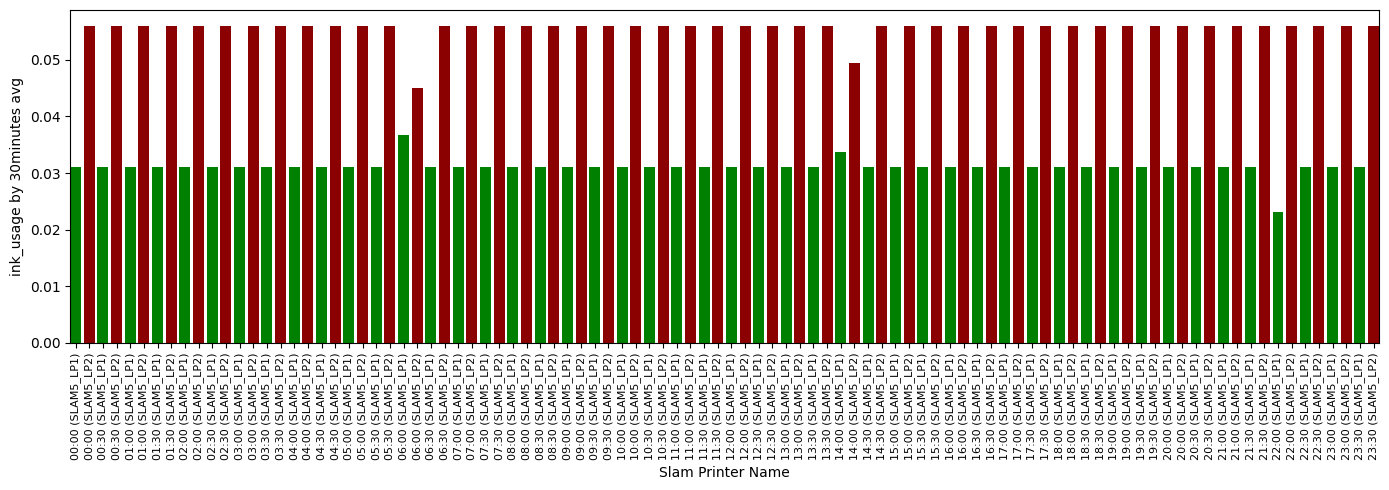

In [21]:
import matplotlib.pyplot as plt

max_val = df_org_PQ['ink_usage'].max()
color_define = {
    'SLAM5_LP1': 'green',
    'SLAM5_LP2': 'darkred'
}

barcolor = df_org_PQ['slam'].map(color_define)
labels_x = df_org_PQ['timestamp'].dt.strftime("%H:%M") + " (" + df_org_PQ['slam'] + ")"

plt.figure(figsize=(14,5))

plt.bar(range(len(df_org_PQ)), df_org_PQ['ink_usage'], color=barcolor)
plt.xticks(range(len(df_org_PQ)), labels_x, rotation=90, fontsize=8)

plt.margins(x=-0)
plt.xlabel('Slam Printer Name')
plt.ylabel('ink_usage by 30minutes avg')

plt.tight_layout()
plt.show()


In [23]:
# für KPI-Erstellung Werte der beiden Drucker konsolieren als Mittelwerte
df_avg_report = df_org_PQ.groupby('slam', as_index=False)['ink_usage'].mean()
df_avg_report


,slam,ink_usage
0,SLAM5_LP1,0.031011
1,SLAM5_LP2,0.055632


In [24]:
KPI_PrintHeadNozzles = round((df_avg_report['ink_usage'].iloc[1] - df_avg_report['ink_usage'].iloc[0]) / df_avg_report['ink_usage'].iloc[0] * 100,1 )

print(f"\nALARM (!) Handlungsempfehlung Labelprintköpfe:\n>>> Slam-Printer 'SLAM5_LP2' Druckkopfdüsen prüfen da --> {KPI_PrintHeadNozzles}% höherer Verbrauch der Tonerfarbe als Slam-Printer 'SLAM5_LP1' innerhalb der letzten 24h !\n\n")



ALARM (!) Handlungsempfehlung Labelprintköpfe:
>>> Slam-Printer 'SLAM5_LP2' Druckkopfdüsen prüfen da --> 79.4% höherer Verbrauch der Tonerfarbe als Slam-Printer 'SLAM5_LP1' innerhalb der letzten 24h !


